<a href="https://colab.research.google.com/github/IshanRavishankar15/23FE10CSE00641-ML/blob/main/Lab11_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 11
## Natural Language Processing

Aim : Understand basic NLP concepts and apply text preprocessing
techniques.

In [20]:
import nltk

# Download the necessary NLTK models and datasets used in this tutorial
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('book')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [46]:
# --- Tokenizing by Word and Sentence ---
from nltk.tokenize import sent_tokenize, word_tokenize

example_string = """
Muad'Dib learned rapidly because his first training was in how to learn.
And the first lesson of all was the basic trust that he could learn.
It's shocking to find how many people do not believe they can learn,
and how many more believe learning to be difficult.
"""

print("--- Sentence Tokenization ---")
for sentence in sent_tokenize(example_string):
    print(f"- {sentence}")

print("\n--- Word Tokenization ---")
print(word_tokenize(example_string))

--- Sentence Tokenization ---
- 
Muad'Dib learned rapidly because his first training was in how to learn.
- And the first lesson of all was the basic trust that he could learn.
- It's shocking to find how many people do not believe they can learn,
and how many more believe learning to be difficult.

--- Word Tokenization ---
["Muad'Dib", 'learned', 'rapidly', 'because', 'his', 'first', 'training', 'was', 'in', 'how', 'to', 'learn', '.', 'And', 'the', 'first', 'lesson', 'of', 'all', 'was', 'the', 'basic', 'trust', 'that', 'he', 'could', 'learn', '.', 'It', "'s", 'shocking', 'to', 'find', 'how', 'many', 'people', 'do', 'not', 'believe', 'they', 'can', 'learn', ',', 'and', 'how', 'many', 'more', 'believe', 'learning', 'to', 'be', 'difficult', '.']


In [47]:
# --- Filtering Stop Words ---
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

worf_quote = "Sir, I protest. I am not a merry man!"
words_in_quote = word_tokenize(worf_quote)

# Load English stop words
stop_words = set(stopwords.words("english"))

# Filtering using a list comprehension for cleaner, pythonic code
filtered_list = [
    word for word in words_in_quote if word.casefold() not in stop_words
]

print("Original words :", words_in_quote)
print("Filtered words :", filtered_list)

Original words : ['Sir', ',', 'I', 'protest', '.', 'I', 'am', 'not', 'a', 'merry', 'man', '!']
Filtered words : ['Sir', ',', 'protest', '.', 'merry', 'man', '!']


In [48]:
# --- Stemming ---
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()

string_for_stemming = """
The crew of the USS Discovery discovered many discoveries.
Discovering is what explorers do.
"""

words_to_stem = word_tokenize(string_for_stemming)

# Stemming each word down to its root
stemmed_words = [stemmer.stem(word) for word in words_to_stem]

print("Stemmed output:")
print(stemmed_words)

Stemmed output:
['the', 'crew', 'of', 'the', 'uss', 'discoveri', 'discov', 'mani', 'discoveri', '.', 'discov', 'is', 'what', 'explor', 'do', '.']


In [49]:
# --- Tagging Parts of Speech ---
from nltk.tokenize import word_tokenize
import nltk

sagan_quote = """
If you wish to make an apple pie from scratch,
you must first invent the universe."""

words_in_sagan_quote = word_tokenize(sagan_quote)
pos_tags = nltk.pos_tag(words_in_sagan_quote)

print("Parts of Speech Tags:")
for word, tag in pos_tags:
    print(f"{word:<12} -> {tag}")

Parts of Speech Tags:
If           -> IN
you          -> PRP
wish         -> VBP
to           -> TO
make         -> VB
an           -> DT
apple        -> NN
pie          -> NN
from         -> IN
scratch      -> NN
,            -> ,
you          -> PRP
must         -> MD
first        -> VB
invent       -> VB
the          -> DT
universe     -> NN
.            -> .


In [50]:
# --- Lemmatizing ---
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

print("Lemmatizing 'scarves' (default noun) :", lemmatizer.lemmatize("scarves"))
print("Lemmatizing 'worst' (default noun)   :", lemmatizer.lemmatize("worst"))

# Specifying pos="a" tells the lemmatizer to treat the word as an adjective
print("Lemmatizing 'worst' (as adjective)   :", lemmatizer.lemmatize("worst", pos="a"))

Lemmatizing 'scarves' (default noun) : scarf
Lemmatizing 'worst' (default noun)   : worst
Lemmatizing 'worst' (as adjective)   : bad


In [52]:
# --- Chunking ---
from nltk.tokenize import word_tokenize
import nltk

lotr_quote = "It's a dangerous business, Frodo, going out your door."
words_in_lotr_quote = word_tokenize(lotr_quote)
lotr_pos_tags = nltk.pos_tag(words_in_lotr_quote)

# Defining a grammar rule for Noun Phrases (NP)
grammar = "NP: {<DT>?<JJ>*<NN>}"
chunk_parser = nltk.RegexpParser(grammar)

tree = chunk_parser.parse(lotr_pos_tags)

print("Chunked Tree:")
print(tree)
# tree.draw()

Chunked Tree:
(S
  It/PRP
  's/VBZ
  (NP a/DT dangerous/JJ business/NN)
  ,/,
  Frodo/NNP
  ,/,
  going/VBG
  out/RP
  your/PRP$
  (NP door/NN)
  ./.)


In [53]:
# --- Chinking ---
import nltk

# Re-using the tagged quote from the Chunking section
# We define a chunk but 'chink' (exclude) adjectives (<JJ>) using }{
grammar = """
Chunk: {<.*>+}
       }<JJ>{"""

chunk_parser = nltk.RegexpParser(grammar)
tree = chunk_parser.parse(lotr_pos_tags)

print("Chinked Tree:")
print(tree)
# tree.draw()

Chinked Tree:
(S
  (Chunk It/PRP 's/VBZ a/DT)
  dangerous/JJ
  (Chunk
    business/NN
    ,/,
    Frodo/NNP
    ,/,
    going/VBG
    out/RP
    your/PRP$
    door/NN
    ./.))


In [54]:
# --- Using Named Entity Recognition (NER) ---
import nltk
from nltk.tokenize import word_tokenize

quote = """
Men like Schiaparelli watched the red planet—it is odd, by-the-bye, that
for countless centuries Mars has been the star of war—but failed to
interpret the fluctuating appearances of the markings they mapped so well.
All that time the Martians must have been getting ready.

During the opposition of 1894 a great light was seen on the illuminated
part of the disk, first at the Lick Observatory, then by Perrotin of Nice,
and then by other observers. English readers heard of it first in the
issue of Nature dated August 2."""

def extract_ne(quote):
    words = word_tokenize(quote)
    tags = nltk.pos_tag(words)

    # binary=True groups all entities just as 'NE' rather than specifying Person/Location
    tree = nltk.ne_chunk(tags, binary=True)

    return set(
        " ".join(i[0] for i in t)
        for t in tree
        if hasattr(t, "label") and t.label() == "NE"
    )

print("Extracted Named Entities:")
print(extract_ne(quote))

Extracted Named Entities:
{'Lick Observatory', 'Mars', 'Nature', 'Schiaparelli', 'Perrotin'}


In [59]:
# --- Getting Text to Analyze ---
# This imports standard texts from the NLTK book module (text1 through text9)
from nltk.book import *

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [60]:
# --- Using a Concordance ---
# Searching the Personals Corpus (text8) for specific words with their surrounding context
print("--- Concordance for 'man' ---")
text8.concordance("man")

print("\n--- Concordance for 'woman' ---")
text8.concordance("woman")

--- Concordance for 'man' ---
Displaying 14 of 14 matches:
 to hearing from you all . ABLE young man seeks , sexy older women . Phone for 
ble relationship . GENUINE ATTRACTIVE MAN 40 y . o ., no ties , secure , 5 ft .
ship , and quality times . VIETNAMESE MAN Single , never married , financially 
ip . WELL DRESSED emotionally healthy man 37 like to meet full figured woman fo
 nth subs LIKE TO BE MISTRESS of YOUR MAN like to be treated well . Bold DTE no
eeks lady in similar position MARRIED MAN 50 , attrac . fit , seeks lady 40 - 5
eks nice girl 25 - 30 serious rship . Man 46 attractive fit , assertive , and k
 40 - 50 sought by Aussie mid 40s b / man f / ship r / ship LOVE to meet widowe
discreet times . Sth E Subs . MARRIED MAN 42yo 6ft , fit , seeks Lady for discr
woman , seeks professional , employed man , with interests in theatre , dining 
 tall and of large build seeks a good man . I am a nonsmoker , social drinker ,
lead to relationship . SEEKING HONEST MAN I am 41 y . o ., 5 

Generating dispersion plot for text8...


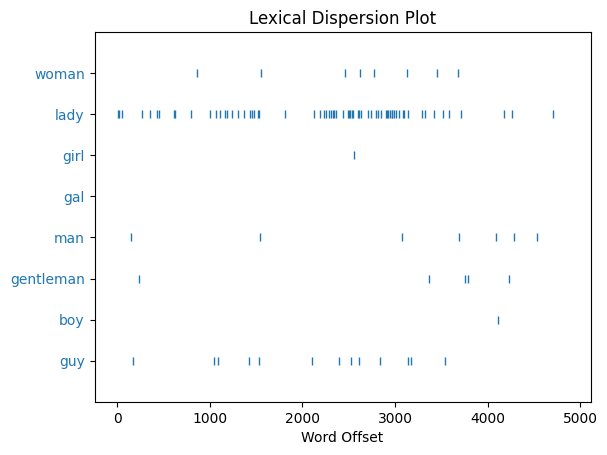

In [61]:
# --- Making a Dispersion Plot ---
# Note: Ensure matplotlib is installed in your environment for this to work
print("Generating dispersion plot for text8...")
text8.dispersion_plot(
    ["woman", "lady", "girl", "gal", "man", "gentleman", "boy", "guy"]
)

In [62]:
# --- Making a Frequency Distribution ---
from nltk import FreqDist

frequency_distribution = FreqDist(text8)

print("Top 20 most common words:")
for word, count in frequency_distribution.most_common(20):
    print(f"{word:<10}: {count}")

meaningful_hapaxes = frequency_distribution.hapaxes()

print("\nFirst 10 words that appear exactly once (hapaxes):")
print(meaningful_hapaxes[:10])

Top 20 most common words:
,         : 539
.         : 353
/         : 110
for       : 99
and       : 74
to        : 74
lady      : 68
-         : 66
seeks     : 60
a         : 52
with      : 44
S         : 36
ship      : 33
&         : 30
relationship: 29
fun       : 28
in        : 27
slim      : 27
build     : 27
o         : 26

First 10 words that appear exactly once (hapaxes):
['35YO', 'Security', 'Guard', 'uniform', 'below', 'Nat', 'Open', 'yr', 'M', 'door']


In [63]:
# --- Finding Collocations ---
print("Collocations in text8 (words that frequently appear together):")
text8.collocations()

Collocations in text8 (words that frequently appear together):
would like; medium build; social drinker; quiet nights; non smoker;
long term; age open; Would like; easy going; financially secure; fun
times; similar interests; Age open; weekends away; poss rship; well
presented; never married; single mum; permanent relationship; slim
build
